In [7]:
library(tidyverse)
library(glue)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 15.7.4

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/envs/r-notebook/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Europe/Brussels
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.8.0      lubridate_1.9.4 forcats_1.0.0   stringr_1.5.2  
 [5] dplyr_1.1.4     purrr_1.1.0     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.3.0    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     compiler_4.3.3     crayon_1.5.3      
 [5] tidyselect_1.2.1   IRdisplay_1.1      systemfonts_1.2.3  scales_1.4.0      
 [9] textshaping_1.0.3  uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3.2    
[13] R6_2.6.1           generics_0.1.4     pillar_1.11.0      RColorBre

In [9]:
galn <- read_tsv("./data-preparation/global-alignment/global_alignment_stats.tsv")
refvref <- read_tsv("./data-preparation/global-alignment/refvref_global_alignment_stats.tsv")


Rows: 142 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 38 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
head(galn)
head(refvref)

seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MN090204.1.9596_cl1_it2.consensus_bcftools,MN090204.1,9247,8756,8701,117,0.013362,9046,9074,2,173,221,0
MN090406.1.8586_cl1_it2.consensus_bcftools,MN090406.1,9031,9005,8944,8,0.000888,9031,9013,0,18,78,0
MW063100.1.8788_cl1_it2.consensus_bcftools,MN090277.1,9328,7963,7942,993,0.124702,9052,9232,276,96,56,0
MK457885.1.8080_cl1_it2.consensus_bcftools,MK457885.1,9015,8764,8677,0,0.000000,9015,8764,0,251,338,0
MK457885.1.8080_cl1_it2.consensus_bcftools,MN090277.1,9307,7225,6887,1715,0.237370,9015,9232,292,75,338,0
U69584.1.9091_cl2_it2.consensus_bcftools,U69584.1,10076,7715,7715,700,0.090732,9238,9217,802,859,0,0


seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MN090277.1,MZ766594.1,9370,7522,7522,1425,0.189444,9232,9085,138,285,0,0
MN090277.1,MN090204.1,9240,8665,8665,401,0.046278,9232,9074,8,166,0,0
MN090277.1,AF443074.1,9338,7604,7604,1327,0.174513,9232,9037,106,301,0,0
MN090277.1,MW881692.1,9279,8050,8050,803,0.099752,9232,8900,47,379,0,0
MN090277.1,MN090437.1,9299,7664,7664,1298,0.169363,9232,9029,67,270,0,0
MN090277.1,MK457885.1,9307,6964,6964,1725,0.247702,9232,8764,75,543,0,0


In [11]:
best_match <- galn%>%group_by(seq1_id)%>%
  arrange(desc(matches))%>%
  slice(1)%>%
  select(seq1_id, best_match=seq2_id)

In [12]:
refvref_orderd <- refvref %>%
    mutate(target = seq2_id, fident = matches/alignment_length, semi_fident = comparable_sites/alignment_length)%>%
    arrange(desc(fident), desc(semi_fident))%>%
    select(target, fident, semi_fident)

In [13]:
selection <- galn%>%
    mutate(target=sub("^([^.]+\\.[^.]+).*", "\\1", seq1_id))%>%
    merge(best_match, by="seq1_id")%>%
    merge(., refvref_orderd, by="target", all.x=TRUE)%>%
    filter(seq2_id == "MN090277.1")%>%
    filter(comparable_sites/alignment_length >= 0.7) # Alignment needs to be somewhat comparable


summary(selection$semi_fident)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7406  0.8028  0.8412  0.8459  0.8698  1.0000 

Warning message in dir.create("./images"):
“'./images' already exists”


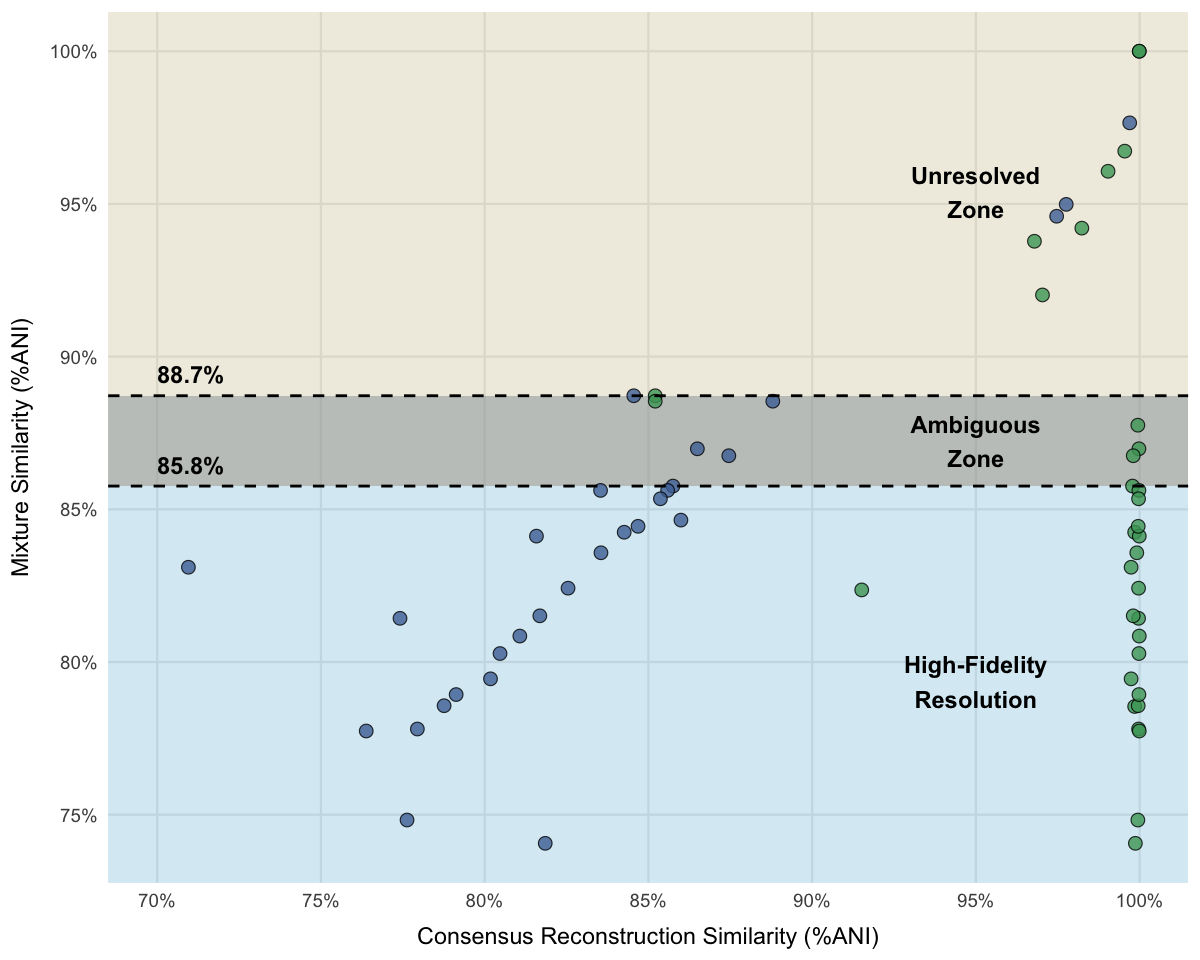

In [15]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Calculate thresholds
threshold1 <- selection %>%
    group_by(target) %>%
    unique()%>%
    filter(n() > 1) %>%
    ungroup() %>%
    summarise(threshold = max(fident)) %>%
    pull(threshold)

threshold2 <- selection %>%
    group_by(target) %>%
    unique()%>%
    filter(n() > 1)%>%
    filter(abs((comparable_sites/alignment_length) - fident) < 0.001) %>%
    ungroup() %>%
    summarise(threshold = max(fident)) %>%
    pull(threshold)

p <- ggplot(selection, aes(x = comparable_sites/alignment_length, y = semi_fident, fill = (best_match == "MN090277.1"))) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = threshold1,
             fill = "#77BEDB", alpha = 0.3) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = threshold1, ymax = threshold2,
             fill = "#7F6E85", alpha = 0.3) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = threshold2, ymax = Inf,
             fill = "#CCC197", alpha = 0.3) +
    geom_point(size = 3.5, alpha = 0.8, shape = 21, color = "black") +
    geom_hline(yintercept = threshold1, linetype = "dashed", color = "black", linewidth = 0.8) +
    geom_hline(yintercept = threshold2, linetype = "dashed", color = "black", linewidth = 0.8) +
    # Points
    # Labels
    annotate("text", x = 0.70, y = threshold1 + 0.007,
             label = sprintf("%.1f%%", threshold1 * 100),
             color = "black", fontface = "bold", size = 5, hjust = 0) +
    annotate("text", x = 0.70, y = threshold2 + 0.007,
             label = sprintf("%.1f%%", threshold2 * 100),
             color = "black" , fontface = "bold", size = 5, hjust = 0) +
    # Zone labels
    annotate("text", x = 0.95, y =(threshold2 + 1.05) / 2,
             label = "Unresolved\nZone", fontface = "bold", size = 5, color = "black") +
    annotate("text", x = 0.95, y = (threshold1 + threshold2) / 2,
             label = "Ambiguous\nZone", fontface = "bold", size = 5, color = "black") +
    annotate("text", x = 0.95, y =  (0.70 + threshold1) / 2,
             label = "High-Fidelity\nResolution", fontface = "bold", size = 5, color = "black") +
    # Scales
    scale_fill_manual(values=c("#4C72A5","#48A365")) +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1),
                       breaks = scales::pretty_breaks(n = 6)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       breaks = scales::pretty_breaks(n = 6)) +
    labs(x = "Consensus Reconstruction Similarity (%ANI)",
         y = "Mixture Similarity (%ANI)",
         fill = "Target Sequence"
        ) +
    theme_minimal(base_size = 14) +
    theme(
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        plot.background = element_blank(),
        legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold")
    )

p
dir.create("./images")
ggsave("./images/reference_impact_zones.png", plot = p, width = 10, height = 8, dpi = 300)
ggsave("../../../Fig/supplfig1.png", plot = p, width = 10, height = 8, dpi = 300)